# Comparison cistrans
Run any plot you need, only run setup and the window you are interested in.
Choose the data from the dropdown menu and adjust global parameters in setup, if needed.

In [1]:
#general imports
# import h5py
# import meteor
# import reciprocalspaceship as rs
import numpy as np
from scipy.ndimage import gaussian_filter

current_path = os.getcwd()
path_parts = current_path.split(os.sep)
idx = path_parts.index("occupancy-estimation")
homepath = os.sep.join(path_parts[:idx + 1])
sys.path.append(homepath)

# my imports
from occupancy import *
from plotting3d import *
from generate_objects import *

In [2]:
%load_ext autoreload 
%autoreload 2

In [3]:
# "Latex style"
import matplotlib
matplotlib.rcParams.update({
    "font.family": "serif",
    "text.usetex": True,
}
)

# Setup

In [4]:
from compare_conds import * 
alpha_xtrs = default_alpha_xtrs()
alpha_trues = np.arange(0.05, 1, 0.1)
noise_levels = [0, 0.05, 0.1, 0.2, 0.3]
res_log, rows = main(alpha_xtrs, alpha_trues, noise_levels )

Running scaleit, see tmp/launch_scaleit.sh
Running scaleit, see tmp/launch_scaleit.sh
intersection point, 0.058 (34.53)
Running scaleit, see tmp/launch_scaleit.sh
intersection point, 0.172 (11.61)
Running scaleit, see tmp/launch_scaleit.sh
intersection point, 0.286 (7.00)
Running scaleit, see tmp/launch_scaleit.sh
intersection point, 0.398 (5.02)
Running scaleit, see tmp/launch_scaleit.sh
intersection point, 0.509 (3.93)
Running scaleit, see tmp/launch_scaleit.sh
intersection point, 0.619 (3.23)
Running scaleit, see tmp/launch_scaleit.sh
intersection point, 0.727 (2.75)
Running scaleit, see tmp/launch_scaleit.sh
intersection point, 0.823 (2.43)
Running scaleit, see tmp/launch_scaleit.sh
intersection point, 0.895 (2.23)
Running scaleit, see tmp/launch_scaleit.sh
intersection point, 0.934 (2.14)
Running scaleit, see tmp/launch_scaleit.sh
intersection point, 0.058 (34.77)
Running scaleit, see tmp/launch_scaleit.sh
intersection point, 0.114 (17.51)
Running scaleit, see tmp/launch_scaleit.s

In [6]:
# res_log = pd.concat((res_log,res_log2))
# res_log2 = res_log

saving in .../time_resolved/occupancy-estimation/plots/vary_noise_occu_pandda_nse.png
saving in .../time_resolved/tex/figs/vary_noise_occu_pandda_nse.pdf


<Figure size 640x480 with 0 Axes>

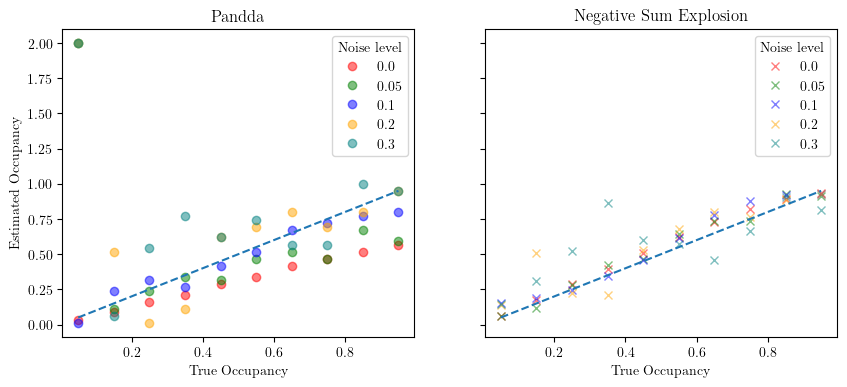

In [10]:
colors = 'r', 'g' ,'b','orange', "teal", "brown"
fig, axs = plt.subplots(1,2, figsize=(10,4), sharey=True)
titles = ["Pandda", "Negative Sum Explosion"]
axs[0].set_ylabel("Estimated Occupancy")
for ax, title in zip(axs, titles):
    ax.set_title(title)
    for color, noise_level in zip(colors, np.unique(res_log.noise)):
        kwargs = {"color":color, "alpha" : 0.5, "label":noise_level}
        rslog = res_log[res_log.noise == noise_level]
        if title=="Pandda":
            ax.plot(rslog.true, rslog.pandda, "o",**kwargs)
        else:
            plt.plot(rslog.true, rslog.neg_sum, "x", **kwargs)
    ax.set_xlabel("True Occupancy")
    ax.plot(rslog.true, rslog.true, "--")
    ax.legend(title="Noise level")
    
save_fig(fig, "vary_noise_occu_pandda_nse")
# colors = 'r', 'g' ,'b','orange'
# plt.figure()
# plt.title()
# for color, noise_level in zip(colors, np.unique(res_log.noise)):
#     kwargs = {"color":color, "alpha" : 0.5, "label":noise_level}
#     rslog = res_log[res_log.noise == noise_level]
#     plt.plot(rslog.true, rslog.neg_sum, "x", **kwargs)
#     # plt.plot(rslog.true, rslog.pandda, "o",**kwargs)
# plt.plot(rslog.true, rslog.true, "--")
# plt.legend(title="Noise level")
# plt.show()
